C:\Users\smani\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\smani\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\smani\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\smani\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\smani\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

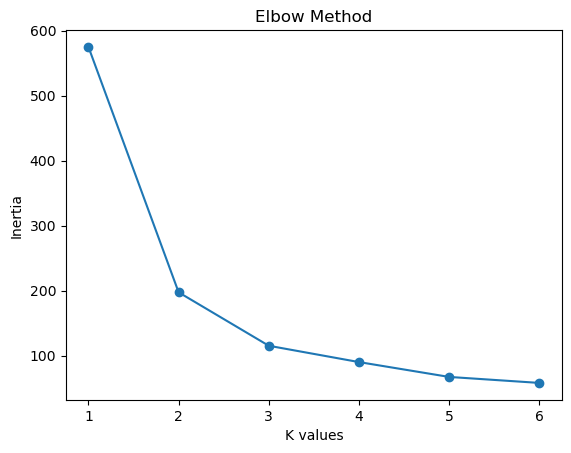

C:\Users\smani\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


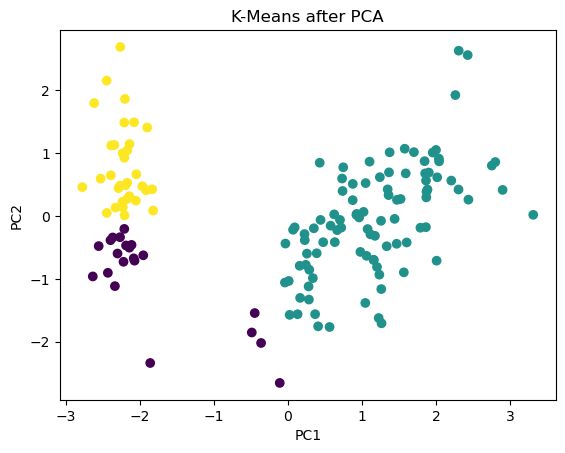

Cluster Labels: [2 0 0 0 2 2 2 2 0 0 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 0 0 2 2 2 0 0 2
 2 0 2 2 0 0 2 2 0 2 0 2 2 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
X = load_iris().data

# Standardize
X = StandardScaler().fit_transform(X)

# PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Elbow method
inertia = []
for k in range(1, 7):
    km = KMeans(n_clusters=k)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(range(1, 7), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K values")
plt.ylabel("Inertia")
plt.show()

# Choose K=3
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_pca)

# Plot clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("K-Means after PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Cluster Labels:", labels)
